In [1]:
import sys, json, os
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             roc_curve, precision_recall_curve)
from sklearn.calibration import calibration_curve
from src.thresholds import (oof_probabilities, threshold_table, operating_point,
                            net_benefit, net_benefit_treat_all)

X_train = pd.read_parquet("../data/processed/X_train.parquet")
y_train = pd.read_parquet("../data/processed/y_train.parquet")["_MICHD"]
final = json.load(open("../reports/final_features.json"))["final"]
y = y_train.values

oof = {}
for name in ["logreg", "xgb", "rf"]:
    oof[name] = oof_probabilities(name, X_train, y_train, final)
    print(name, "done")

pd.DataFrame(oof).to_parquet("../data/processed/oof_probabilities.parquet")

logreg done
xgb done
rf done


prevalence: 0.0936   Brier of 'everyone gets the base rate': 0.0848


,model,roc_auc,pr_auc,brier,mean_prediction
0,logreg,0.8269,0.3354,0.0722,0.0936
1,xgb,0.8303,0.3405,0.0718,0.0935
2,rf,0.8287,0.3382,0.0721,0.0935


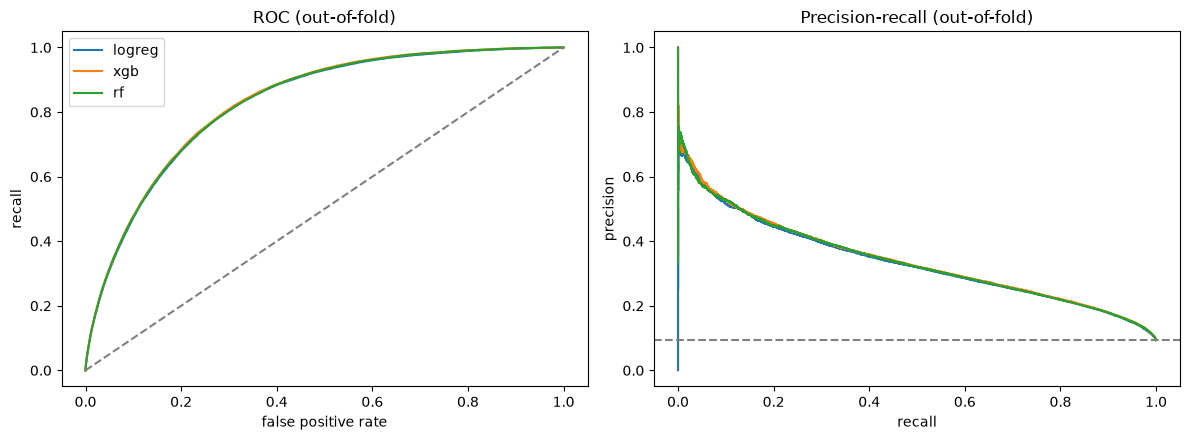

In [2]:
rows = [{"model": n, "roc_auc": roc_auc_score(y, p), "pr_auc": average_precision_score(y, p),
         "brier": brier_score_loss(y, p), "mean_prediction": p.mean()} for n, p in oof.items()]
print("prevalence:", round(y.mean(), 4),
      "  Brier of 'everyone gets the base rate':", round(y.mean() * (1 - y.mean()), 4))
display(pd.DataFrame(rows).round(4))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for n, p in oof.items():
    fpr, tpr, _ = roc_curve(y, p)
    ax[0].plot(fpr, tpr, label=n)
    pr, rc, _ = precision_recall_curve(y, p)
    ax[1].plot(rc, pr, label=n)
ax[0].plot([0, 1], [0, 1], "--", color="grey")
ax[0].set(xlabel="false positive rate", ylabel="recall", title="ROC (out-of-fold)")
ax[1].axhline(y.mean(), ls="--", color="grey")
ax[1].set(xlabel="recall", ylabel="precision", title="Precision-recall (out-of-fold)")
ax[0].legend()
plt.tight_layout()
plt.savefig("../reports/figures/10_roc_pr_oof.png", dpi=300, bbox_inches="tight")
plt.show()

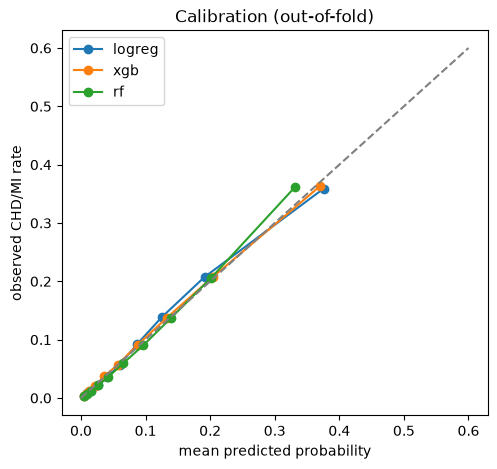

In [3]:
plt.figure(figsize=(5.5, 5))
for n, p in oof.items():
    frac, mean_pred = calibration_curve(y, p, n_bins=10, strategy="quantile")
    plt.plot(mean_pred, frac, marker="o", label=n)
top = 0.6
plt.plot([0, top], [0, top], "--", color="grey")
plt.xlabel("mean predicted probability")
plt.ylabel("observed CHD/MI rate")
plt.title("Calibration (out-of-fold)")
plt.legend()
plt.savefig("../reports/figures/11_calibration_oof.png", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
for n in ["xgb", "logreg"]:
    print(f"\n=== {n} ===")
    print(threshold_table(y, oof[n]).round(3).to_string(index=False))


=== xgb ===
         goal  threshold  recall  specificity  precision  flagged_pct  flagged_per_case_found
recall >= 70%      0.129   0.700        0.790      0.256       25.556                   3.902
recall >= 80%      0.093   0.800        0.710      0.221       33.806                   4.516
recall >= 90%      0.051   0.900        0.575      0.179       46.989                   5.580
       max F2      0.100   0.777        0.730      0.229       31.764                   4.367

=== logreg ===
         goal  threshold  recall  specificity  precision  flagged_pct  flagged_per_case_found
recall >= 70%      0.119   0.700        0.786      0.252       25.965                   3.964
recall >= 80%      0.088   0.800        0.705      0.219       34.253                   4.576
recall >= 90%      0.054   0.900        0.568      0.177       47.584                   5.650
       max F2      0.096   0.777        0.727      0.227       32.053                   4.406


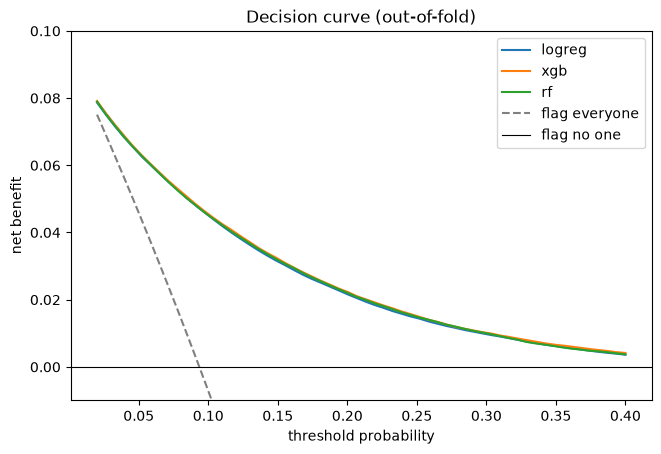

In [5]:
ts = np.linspace(0.02, 0.40, 60)
plt.figure(figsize=(7.5, 4.8))
for n, p in oof.items():
    plt.plot(ts, net_benefit(y, p, ts), label=n)
plt.plot(ts, net_benefit_treat_all(y, ts), "--", color="grey", label="flag everyone")
plt.axhline(0, color="black", lw=0.8, label="flag no one")
plt.ylim(-0.01, 0.10)
plt.xlabel("threshold probability")
plt.ylabel("net benefit")
plt.title("Decision curve (out-of-fold)")
plt.legend()
plt.savefig("../reports/figures/12_decision_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## Threshold and calibration findings

Out-of-fold predictions (5-fold, full 362k-row training set, 14 features, tuned unweighted models) were used so that curves and thresholds reflect training data only.

**Discrimination.** ROC-AUC / PR-AUC: logistic regression 0.827 / 0.335, Random Forest 0.829 / 0.338, XGBoost 0.830 / 0.341 (random PR-AUC = 0.094). Differences between models are ≤ 0.003 ROC-AUC.

**Calibration.** All three models are well calibrated without post-hoc correction: mean predicted risk equals prevalence (0.0935 vs 0.0936), reliability curves follow the diagonal, and Brier scores (≈ 0.072) beat a constant base-rate forecast (0.085) by roughly 15%. The highest-risk decile deviates by about 0.02 (over-confident for logistic regression/XGBoost, slightly under-confident for Random Forest).

**Threshold trade-offs (XGBoost).** Recall ≥ 70% / 80% / 90% requires thresholds of 0.129 / 0.093 / 0.051, flagging 25.6% / 33.8% / 47.0% of people with precision 25.6% / 22.1% / 17.9% (about 3.9 / 4.5 / 5.6 people flagged per true case). The max-F2 threshold (0.100) coincides with the 80%-recall point. Logistic regression gives nearly identical trade-offs.

**Equivalence with class weighting.** The class-weighted model at threshold 0.5 (recall 0.79, specificity 0.71, precision 0.22) matches the unweighted model at threshold ≈ 0.09, confirming that weighting merely shifts the operating point while degrading probability calibration.

**Interpretation.** At this prevalence and AUC, high sensitivity necessarily means many false alarms; the model is suited to screening and prioritisation, not diagnosis.